In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general de visualizacion
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos
df = pd.read_csv('i40.csv')

print('Dimensiones del dataset:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())

display(df.head())

Dimensiones del dataset: (14521, 9)

Tipos de datos:
idx                   int64
parent_device_id      int64
product_type            str
air_temp [K]        float64
process_temp [K]    float64
speed [RPM]           int64
torque [Nm]         float64
tool_wear [min]       int64
target                  str
dtype: object

Valores nulos por columna:
idx                  0
parent_device_id     0
product_type         0
air_temp [K]        40
process_temp [K]     0
speed [RPM]          0
torque [Nm]          0
tool_wear [min]      0
target               0
dtype: int64


,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


## Parte 1 - Analisis exploratorio de datos (EDA)

En esta seccion se analizan:
- Medidas de tendencia central.
- Medidas de dispersion.
- Distribuciones.
- Proporciones.
- Relaciones entre variables.

In [85]:
# Variables numericas y categoricas
exclude_num_cols = {'idx', 'parent_device_id', 'parent_id'}
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude_num_cols]
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print('Columnas numericas (sin idx y parent_id):', num_cols)
print('Columnas categoricas:', cat_cols)

# Medidas de tendencia central
central = pd.DataFrame({
    'media': df[num_cols].mean(numeric_only=True),
    'mediana': df[num_cols].median(numeric_only=True)
})

# Moda (puede haber mas de una, se toma la primera)
central['moda'] = [df[c].mode(dropna=True).iloc[0] if not df[c].mode(dropna=True).empty else np.nan for c in num_cols]

# Medidas de dispersion
dispersion = pd.DataFrame({
    'min': df[num_cols].min(numeric_only=True),
    'max': df[num_cols].max(numeric_only=True),
    'rango': df[num_cols].max(numeric_only=True) - df[num_cols].min(numeric_only=True),
    'varianza': df[num_cols].var(numeric_only=True),
    'desvio_std': df[num_cols].std(numeric_only=True),
    'coef_variacion': df[num_cols].std(numeric_only=True) / df[num_cols].mean(numeric_only=True)
})

print('--- Medidas de tendencia central ---')
display(central.round(3))
print('--- Medidas de dispersion ---')
display(dispersion.round(3))

Columnas numericas (sin idx y parent_id): ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
Columnas categoricas: ['product_type', 'target']
--- Medidas de tendencia central ---


,media,mediana,moda
air_temp [K],300.479,300.60,300.7
process_temp [K],310.165,310.32,310.6
speed [RPM],1513.389,1423.00,1377.0
torque [Nm],44.956,46.70,35.8
tool_wear [min],124.922,127.00,208.0


--- Medidas de dispersion ---


,min,max,rango,varianza,desvio_std,coef_variacion
air_temp [K],295.3,304.5,9.2,3.813,1.953,0.006
process_temp [K],305.7,313.8,8.1,1.768,1.330,0.004
speed [RPM],-1.0,2886.0,2887.0,98347.575,313.604,0.207
torque [Nm],3.8,76.6,72.8,202.397,14.227,0.316
tool_wear [min],0.0,253.0,253.0,4914.850,70.106,0.561


In [86]:
# Resumen estadistico ampliado
summary = df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
summary['IQR'] = summary['75%'] - summary['25%']
summary['asimetria'] = df[num_cols].skew(numeric_only=True)
summary['curtosis'] = df[num_cols].kurt(numeric_only=True)

print('--- Resumen estadistico por variable numerica ---')
display(summary.round(3))

--- Resumen estadistico por variable numerica ---


,count,mean,std,min,25%,50%,75%,max,IQR,asimetria,curtosis
air_temp [K],14481.0,300.479,1.953,295.3,298.90,300.60,302.20,304.5,3.30,-0.220,-0.941
process_temp [K],14521.0,310.165,1.330,305.7,309.20,310.32,311.09,313.8,1.89,-0.220,-0.236
speed [RPM],14521.0,1513.389,313.604,-1.0,1354.00,1423.00,1561.00,2886.0,207.00,2.080,7.991
torque [Nm],14521.0,44.956,14.227,3.8,35.99,46.70,55.00,76.6,19.01,-0.522,-0.024
tool_wear [min],14521.0,124.922,70.106,0.0,64.00,127.00,193.00,253.0,129.00,-0.165,-1.295


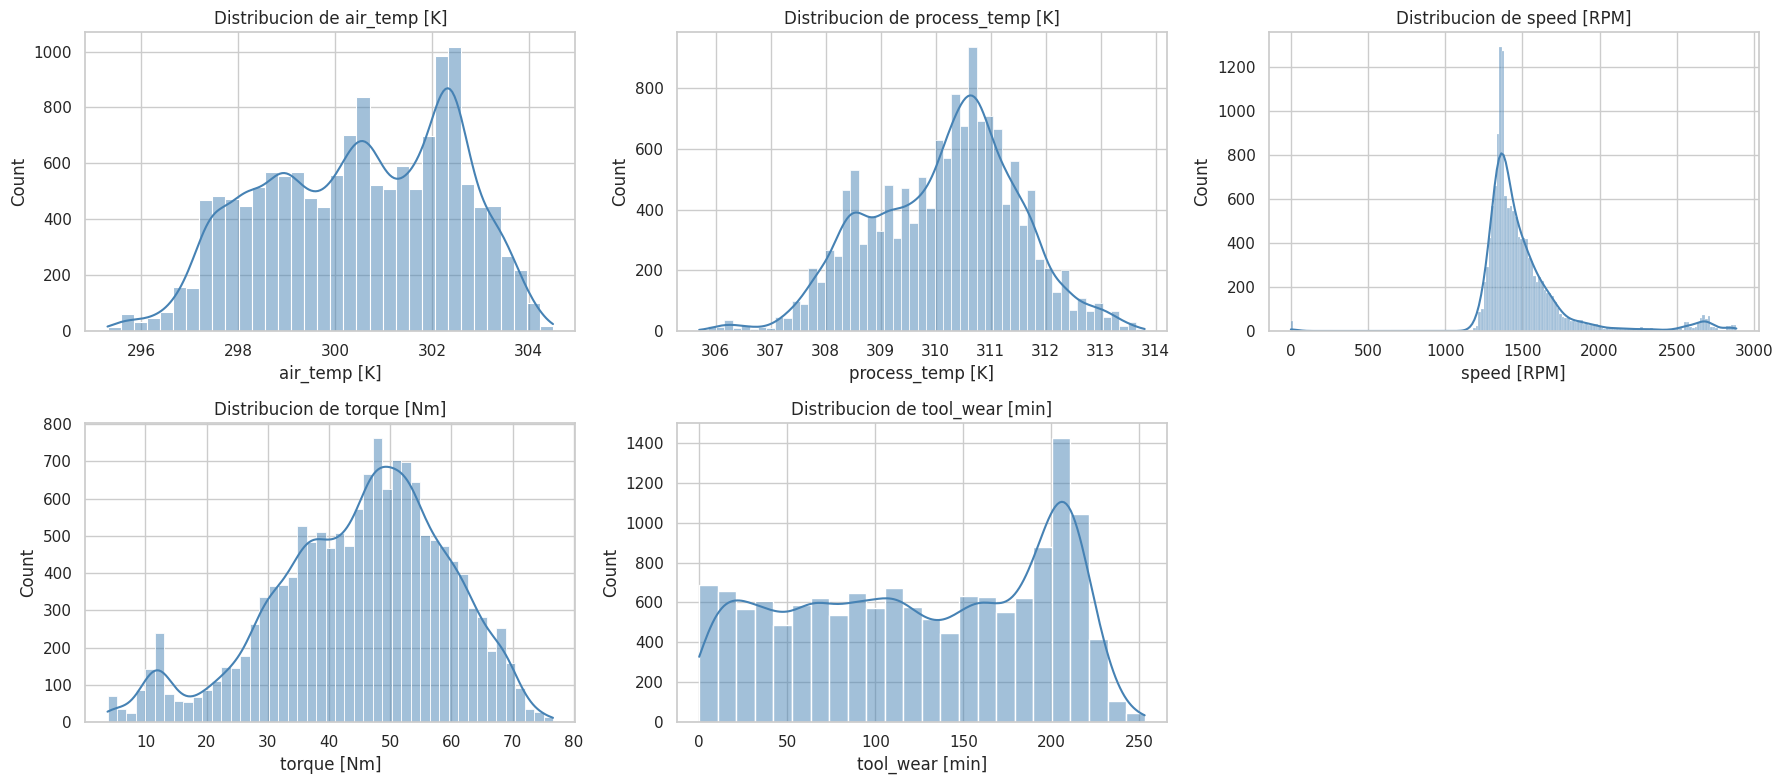

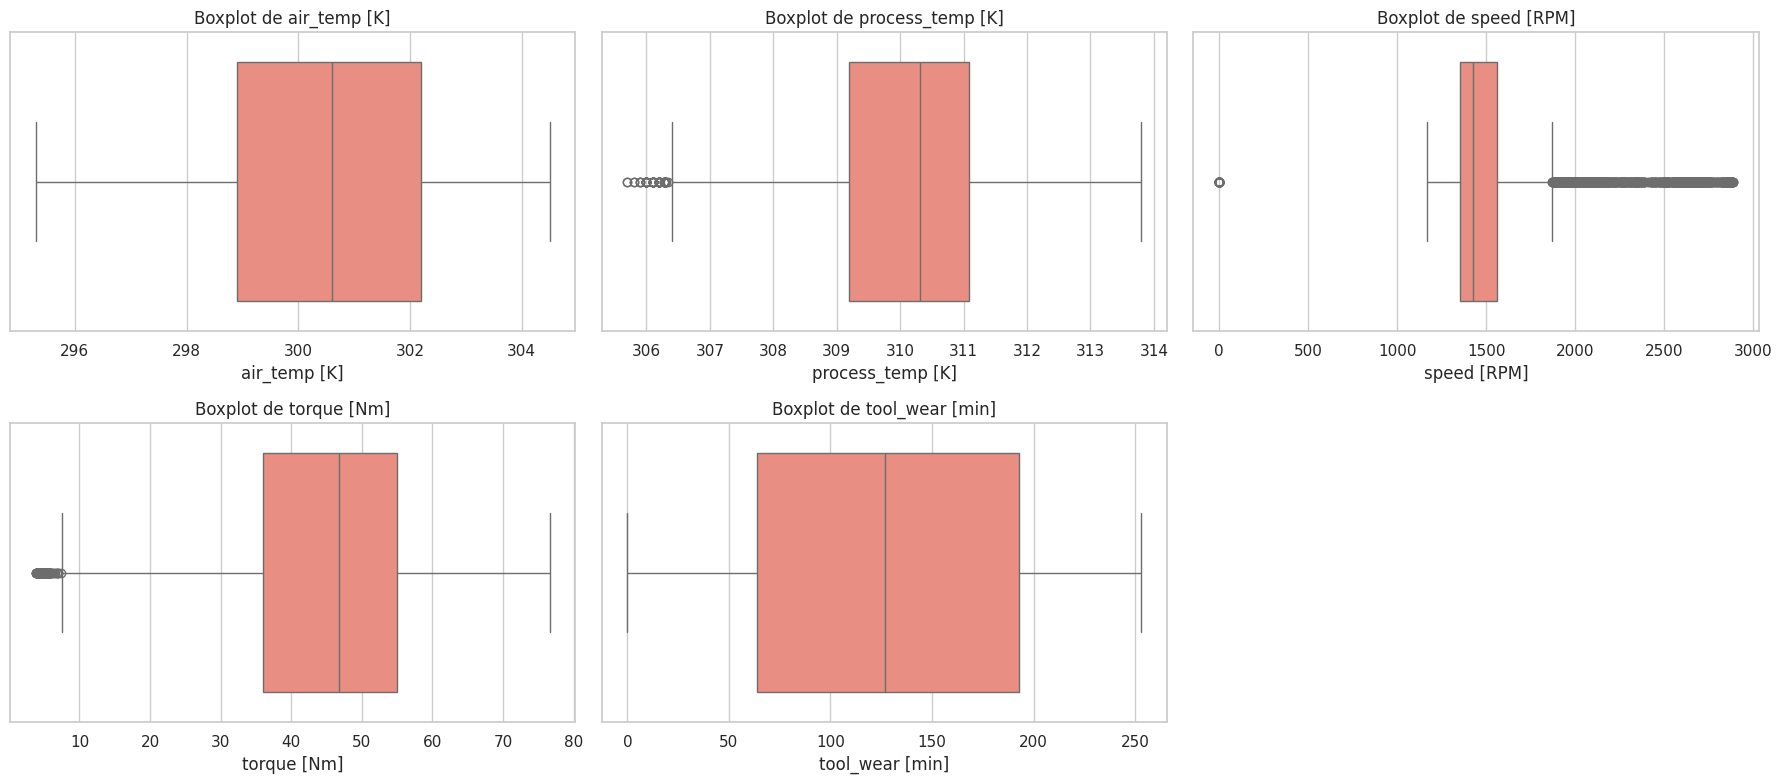

In [87]:
# Distribuciones: histogramas con KDE
n = len(num_cols)
rows = int(np.ceil(n / 3))
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribucion de {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Boxplots para detectar dispersion y posibles outliers
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot de {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


--- Proporciones de product_type (%) ---


,porcentaje
product_type,
L,71.36
M,18.53
H,10.11


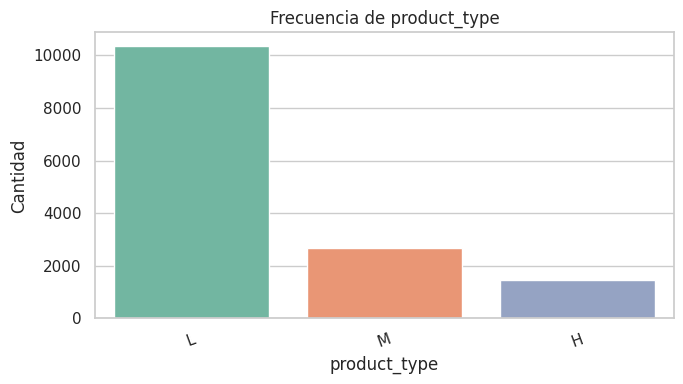


--- Proporciones de target (%) ---


,porcentaje
target,
failure,51.53
normal,48.47


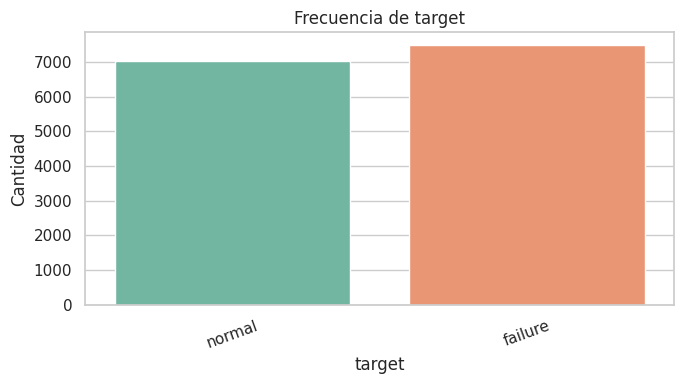

In [88]:
# Proporciones de variables categoricas
for col in cat_cols:
    prop = df[col].value_counts(normalize=True).mul(100).round(2)
    print(f'\n--- Proporciones de {col} (%) ---')
    display(prop.to_frame(name='porcentaje'))

    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
    plt.title(f'Frecuencia de {col}')
    plt.xlabel(col)
    plt.ylabel('Cantidad')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

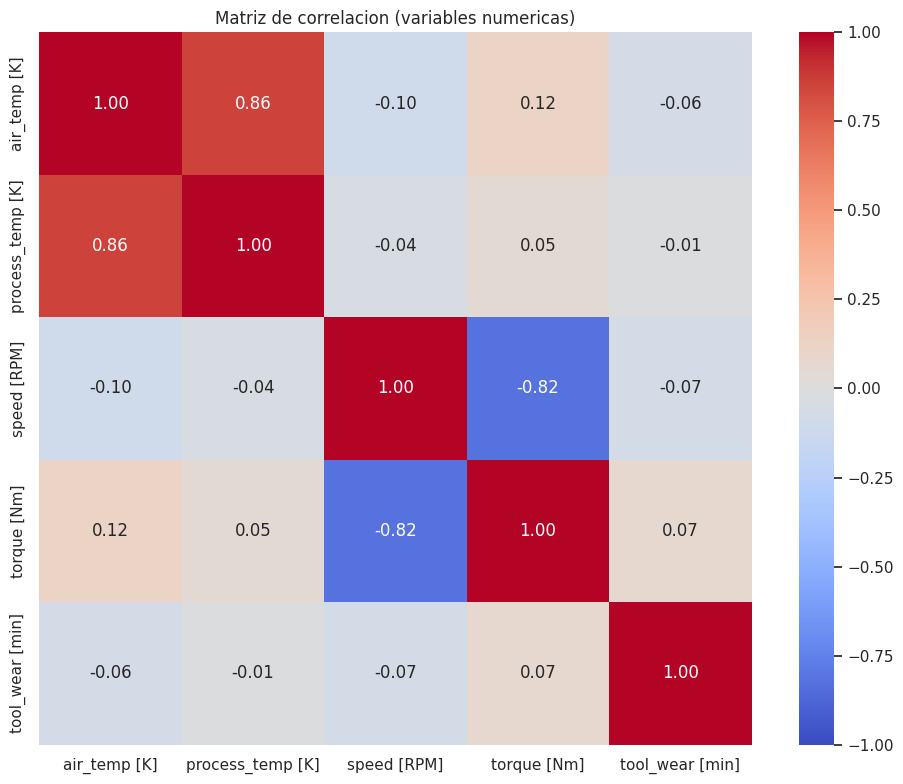

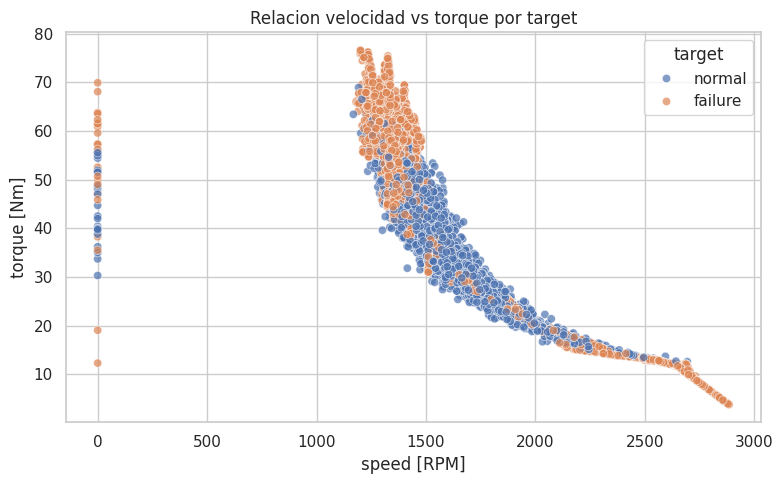

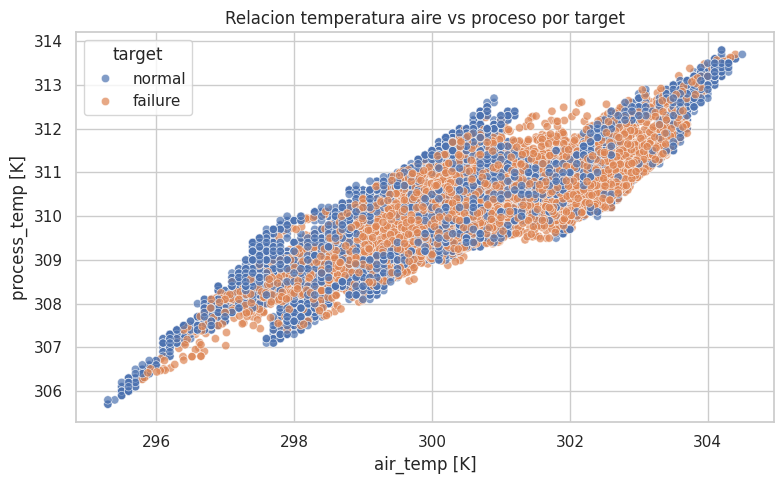

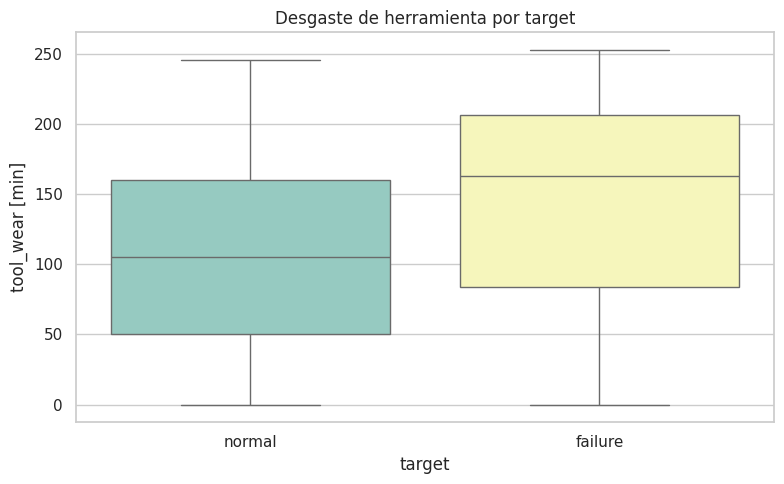

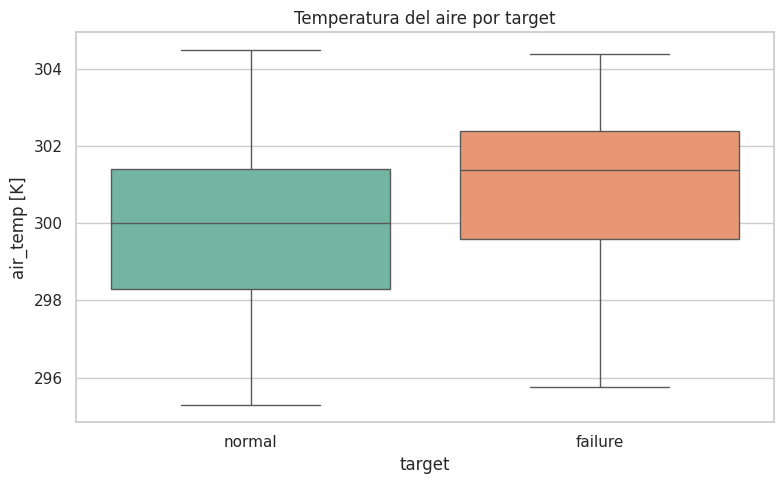

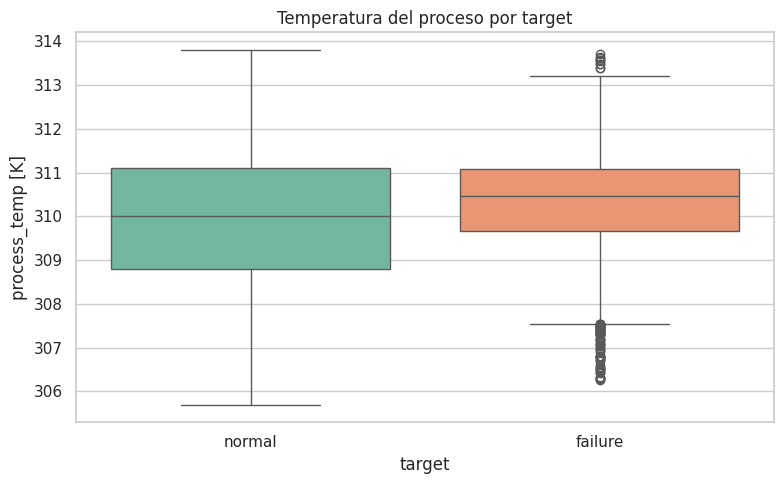

--- Proporcion de product_type por target ---


target,failure,normal
product_type,,
H,0.098,0.104
L,0.829,0.591
M,0.073,0.304


In [89]:
# Relaciones entre variables numericas: correlacion
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, vmin=-1, vmax=1)
plt.title('Matriz de correlacion (variables numericas)')
plt.tight_layout()
plt.show()

# Relacion entre variables y clase objetivo (si existe)
if 'target' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='speed [RPM]', y='torque [Nm]', hue='target', alpha=0.7)
    plt.title('Relacion velocidad vs torque por target')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='air_temp [K]', y='process_temp [K]', hue='target', alpha=0.7)
    plt.title('Relacion temperatura aire vs proceso por target')
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='target', y='tool_wear [min]', hue='target', palette='Set3', legend=False)
    plt.title('Desgaste de herramienta por target')
    plt.tight_layout()
    plt.show()

    # Relacion analoga: RPM (speed) vs target
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='target', y='air_temp [K]', hue='target', palette='Set2', legend=False)
    plt.title('Temperatura del aire por target')
    plt.tight_layout()
    plt.show()
    
    # Relacion analoga: RPM (speed) vs target
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='target', y='process_temp [K]', hue='target', palette='Set2', legend=False)
    plt.title('Temperatura del proceso por target')
    plt.tight_layout()
    plt.show()

    # Tabla cruzada de proporciones
    if 'product_type' in df.columns:
        cross = pd.crosstab(df['product_type'], df['target'], normalize='columns').round(3)
        print('--- Proporcion de product_type por target ---')
        display(cross)

## Conclusiones principales

- La variable `target` esta relativamente balanceada: ~51.53% `failure` y ~48.47% `normal`.
- `product_type` esta desbalanceada a favor de `L` (~71.36%), seguida de `M` y `H`.
- Hay una correlacion positiva alta entre `air_temp [K]` y `process_temp [K]` (~0.86).
- Hay una correlacion negativa fuerte entre `speed [RPM]` y `torque [Nm]` (~-0.82).
- El `tool_wear [min]` tiende a ser mayor en observaciones con `failure` que en `normal`.
- Se observan valores atipicos en `speed [RPM]` y en menor medida en otras variables, visibles en los boxplots.

## Parte 2 - Preprocesamiento para modelos de aprendizaje automatico

En esta seccion se realiza el preprocesamiento del dataset para dejarlo listo para modelado.

In [90]:
# 1) Analisis de variables y limpieza inicial

df_prep = df.copy()

# Definiciones de columnas
id_cols = [c for c in ['idx', 'parent_device_id', 'parent_id'] if c in df_prep.columns]
target_col = 'target'

if target_col not in df_prep.columns:
    raise ValueError('No se encontro la columna target en el dataset.')

# Eliminar identificadores para modelado
if id_cols:
    df_prep = df_prep.drop(columns=id_cols)

# Separar tipos de variables
num_cols_prep = [c for c in df_prep.select_dtypes(include=np.number).columns if c != target_col]
cat_cols_prep = [c for c in df_prep.select_dtypes(exclude=np.number).columns if c != target_col]

print('Columnas eliminadas (identificadores):', id_cols)
print('Variables numericas para modelado:', num_cols_prep)
print('Variables categoricas para modelado:', cat_cols_prep)
print('Variable objetivo:', target_col)

# Valores faltantes y duplicados
missing_before = df_prep.isnull().sum().sort_values(ascending=False)
print('\nValores faltantes antes de imputar:')
display(missing_before[missing_before > 0].to_frame('nulos'))

print('Filas duplicadas:', int(df_prep.duplicated().sum()))
df_prep = df_prep.drop_duplicates().reset_index(drop=True)

# Valores erroneos simples (RPM no puede ser <= 0)
if 'speed [RPM]' in df_prep.columns:
    wrong_rpm = (df_prep['speed [RPM]'] <= 0).sum()
    print('Registros con RPM <= 0:', int(wrong_rpm))
    df_prep.loc[df_prep['speed [RPM]'] <= 0, 'speed [RPM]'] = np.nan

# Imputacion con KMeans para pares de variables fuertemente correlacionadas
from sklearn.cluster import KMeans

def impute_with_kmeans(df, target_col, predictor_col, n_clusters=5):
    """
    Imputa los NaN de target_col usando KMeans entrenado sobre
    los registros validos de (predictor, target). Asigna el valor
    del centroide mas cercano en la dimension del predictor.
    """
    nan_mask = df[target_col].isna()
    if nan_mask.sum() == 0:
        return df

    # Si el predictor tambien es NaN en esos registros, no se puede imputar ahora
    usable_mask = nan_mask & df[predictor_col].notna()
    if usable_mask.sum() == 0:
        return df

    valid = df[target_col].notna()
    if valid.sum() < 2:
        return df

    n = min(n_clusters, int(valid.sum()))
    kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
    kmeans.fit(df.loc[valid, [predictor_col, target_col]])

    centroids = kmeans.cluster_centers_
    for idx in df[usable_mask].index:
        p_val = df.at[idx, predictor_col]
        nearest = np.argmin(np.abs(centroids[:, 0] - p_val))
        df.at[idx, target_col] = centroids[nearest, 1]

    return df

# Speed vs Torque (corr ~ -0.925)
if 'speed [RPM]' in df_prep.columns and 'torque [Nm]' in df_prep.columns:
    df_prep = impute_with_kmeans(df_prep, 'speed [RPM]', 'torque [Nm]')

# Air temp vs Process temp (corr ~ 0.858)
if 'air_temp [K]' in df_prep.columns and 'process_temp [K]' in df_prep.columns:
    df_prep = impute_with_kmeans(df_prep, 'air_temp [K]', 'process_temp [K]')

# Imputacion de faltantes para el resto (median/moda)
for c in num_cols_prep:
    df_prep[c] = df_prep[c].fillna(df_prep[c].median())
for c in cat_cols_prep:
    moda = df_prep[c].mode(dropna=True)
    if not moda.empty:
        df_prep[c] = df_prep[c].fillna(moda.iloc[0])

print('\nValores faltantes despues de imputar:')
display(df_prep.isnull().sum().to_frame('nulos'))

Columnas eliminadas (identificadores): ['idx', 'parent_device_id']
Variables numericas para modelado: ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
Variables categoricas para modelado: ['product_type']
Variable objetivo: target

Valores faltantes antes de imputar:


,nulos
air_temp [K],40


Filas duplicadas: 72
Registros con RPM <= 0: 47

Valores faltantes despues de imputar:


,nulos
product_type,0
air_temp [K],0
process_temp [K],0
speed [RPM],0
torque [Nm],0
tool_wear [min],0
target,0


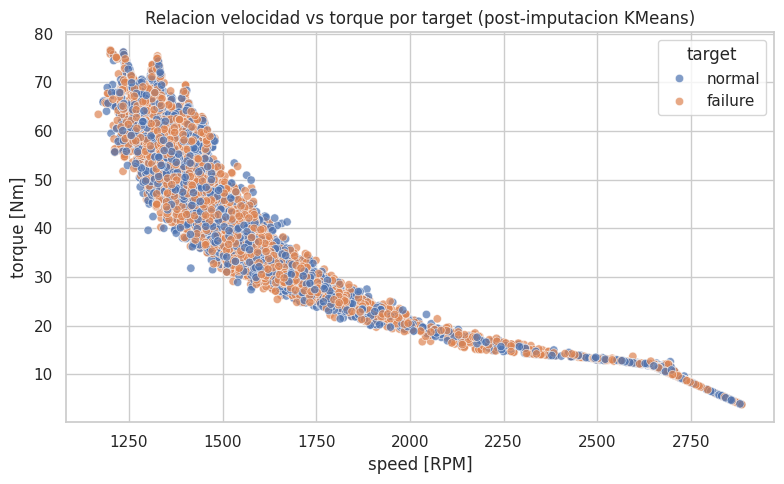

In [91]:
# Scatter post-imputacion KMeans: speed vs torque (con target original)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_prep, x='speed [RPM]', y='torque [Nm]', hue=df['target'], alpha=0.7)
plt.title('Relacion velocidad vs torque por target (post-imputacion KMeans)')
plt.tight_layout()
plt.show()


In [92]:
# Eliminacion de variables altamente correlacionadas (antes del clipping)
# Criterio: para pares con |correlacion| > 0.8, se elimina la variable
# que tenga mayor correlacion promedio con el resto de las features.

corr_matrix = df_prep[num_cols_prep].corr(numeric_only=True).abs()

# Media de correlacion absoluta de cada variable con las demas
mean_corr = corr_matrix.mean(axis=1)

umbral = 0.8
cols_to_drop = set()
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if corr_matrix.iloc[i, j] > umbral:
            var_i = cols[i]
            var_j = cols[j]
            # Eliminar la que tenga mayor correlacion promedio con el resto
            if mean_corr[var_i] > mean_corr[var_j]:
                cols_to_drop.add(var_i)
            else:
                cols_to_drop.add(var_j)

if cols_to_drop:
    print('Variables eliminadas por alta correlacion:', sorted(cols_to_drop))
    df_prep = df_prep.drop(columns=list(cols_to_drop))
    num_cols_prep = [c for c in num_cols_prep if c not in cols_to_drop]
else:
    print('No se detectaron pares con correlacion > 0.8')

print('Variables numericas restantes:', num_cols_prep)

Variables eliminadas por alta correlacion: ['air_temp [K]', 'torque [Nm]']
Variables numericas restantes: ['process_temp [K]', 'speed [RPM]', 'tool_wear [min]']


Resumen de outliers detectados (antes del tratamiento):


,variable,outliers,porcentaje_outliers
1,speed [RPM],1128,7.81
0,process_temp [K],67,0.46
2,tool_wear [min],0,0.00


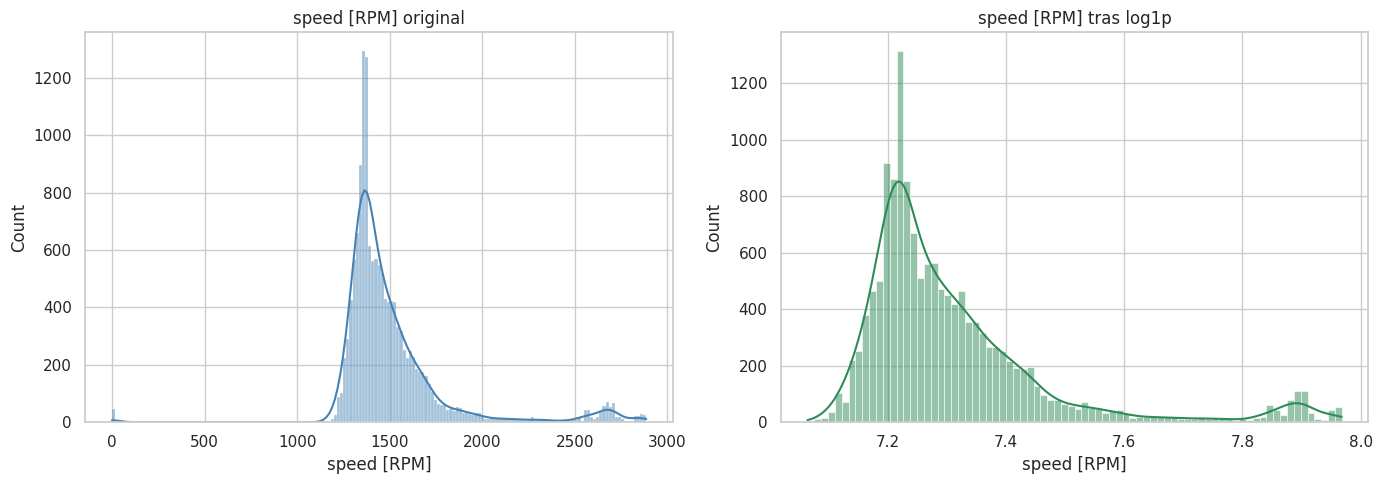

In [93]:
# 2) Valores atipicos (IQR) y tratamiento
outlier_summary = []

for c in num_cols_prep:
    q1 = df_prep[c].quantile(0.25)
    q3 = df_prep[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    out_count = ((df_prep[c] < lower) | (df_prep[c] > upper)).sum()
    outlier_summary.append({
        'variable': c,
        'outliers': int(out_count),
        'porcentaje_outliers': round(100 * out_count / len(df_prep), 2)
    })

    # Para speed [RPM] usamos log1p en lugar de clipping (los valores altos son reales)
    if c == 'speed [RPM]':
        df_prep[c] = np.log1p(df_prep[c])
    else:
        # Clipping para limitar el impacto de extremos sin eliminar filas
        df_prep[c] = df_prep[c].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_summary).sort_values('porcentaje_outliers', ascending=False)
print('Resumen de outliers detectados (antes del tratamiento):')
display(outlier_df)

# Mostrar efecto de la transformacion log en speed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['speed [RPM]'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('speed [RPM] original')
sns.histplot(df_prep['speed [RPM]'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('speed [RPM] tras log1p')
plt.tight_layout()
plt.show()

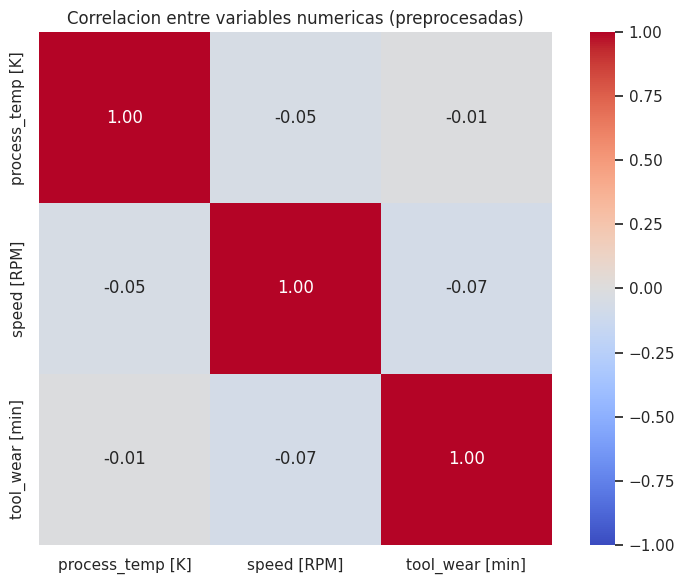

Pares con |correlacion| >= 0.8:
No se detectaron pares por encima del umbral.


In [94]:
# 3) Correlacion entre variables
corr_prep = df_prep[num_cols_prep].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_prep, annot=True, fmt='.2f', cmap='coolwarm', square=True, vmin=-1, vmax=1)
plt.title('Correlacion entre variables numericas (preprocesadas)')
plt.tight_layout()
plt.show()

# Pares con alta correlacion absoluta
threshold = 0.8
high_corr_pairs = []
cols = corr_prep.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr_prep.iloc[i, j]
        if abs(val) >= threshold:
            high_corr_pairs.append((cols[i], cols[j], round(float(val), 3)))

print(f'Pares con |correlacion| >= {threshold}:')
if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs, columns=['var_1', 'var_2', 'corr'], ))
else:
    print('No se detectaron pares por encima del umbral.')

In [107]:
from imblearn.under_sampling import RandomUnderSampler
# 4) Procesamiento de categoricas, balance y normalizacion

# Separacion X/y
y = df_prep[target_col].copy()
X = df_prep.drop(columns=[target_col]).copy()

# Codificacion de variables categoricas con one-hot encoding
X_encoded = pd.get_dummies(X, columns=cat_cols_prep, drop_first=True)

# Variable objetivo a binaria para modelos de clasificacion
# failure -> 1, normal -> 0
y_bin = y.map({'failure': 1, 'normal': 0})

print('Shape X original:', X.shape)
print('Shape X codificada:', X_encoded.shape)
print('Distribucion original de target:')
display((y.value_counts(normalize=True) * 100).round(2).to_frame('porcentaje'))

# Balance del conjunto de datos (undersampling de la clase mayoritaria)
# Reducir la mayoritaria en proporcion segun la variable minoritaria.
undersampler = RandomUnderSampler()
X_bal, y_bal = undersampler.fit_resample(X_encoded, y_bin)

print('Distribucion balanceada de target_bin:')
display((y_bal.value_counts(normalize=True) * 100).round(2).to_frame('porcentaje'))

# Normalizacion estandar (z-score) en columnas numericas
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
num_cols_encoded = [c for c in num_cols_prep if c in X_bal.columns
]
X_scaled = X_bal.copy()
X_scaled[num_cols_encoded] = scaler.fit_transform(X_scaled[num_cols_encoded])   


print('Columnas normalizadas (z-score):', num_cols_encoded)
print('Shape final X_scaled:', X_scaled.shape)
print('Shape final y_bal:', y_bal.shape)

display(X_scaled.head())

Shape X original: (14449, 4)
Shape X codificada: (14449, 5)
Distribucion original de target:


,porcentaje
target,
failure,51.28
normal,48.72


Distribucion balanceada de target_bin:


,porcentaje
target,
0,50.0
1,50.0


Columnas normalizadas (z-score): ['process_temp [K]', 'speed [RPM]', 'tool_wear [min]']
Shape final X_scaled: (14078, 5)
Shape final y_bal: (14078,)


,process_temp [K],speed [RPM],tool_wear [min],product_type_L,product_type_M
0,0.883445,0.020441,0.468088,True,False
1,0.938746,0.022319,0.343885,True,False
4,0.984138,0.023857,0.175796,True,False
5,0.998386,0.023586,0.051663,False,False
9,0.933533,0.022605,0.357779,False,False
